# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [121]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [122]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [123]:
# mostrar las primeras 5 filas de plans
plans.head()



,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [124]:
# mostrar las primeras 5 filas de users
users.head()



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [125]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

In [126]:
users.describe()
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [127]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [128]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [129]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [130]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [131]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [132]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

#Diagnóstico de Valores Nulos, al analizar un dataset de 4000 registros. 

##City tiene 469 nulos (11.7%) nivel intermedio de ausencia (mayor a 5% menor a 30%), no recomiendo eliminar, sino mantener como NAN, ya que es una variable relevante para el análisis que podría afectar la muestra.

##Churn_date tiene 3534 nulos, que es nivel de ausencia muy representativo 88.35% lo que implica que la mayoria de clientes siguen activos, el resto canceló. Se recomienda no eliminar, ya que no es un dato faltante.

##Usage - la fecha tiene 50 nulos (0.125%) por lo tanto se recomienda eliminar filas o convertir con coerce, su impacto es mìnimo dada la muestra.

##en la variable duracion hay 22,076 nulos (= 55.19%), es muy alto pero aplica solo cuando hay llamadas, tambièn length con 17,896 nulos (44.74%), pero aplica cuando hay textos, entonces también deben considerarse aunque parezca error.

##En resumen, el faltante real es city habra que mantener, date, se puede eliminar los faltantes y churn_date, duration y length son estructurales y variable sdependiuentes que tambièn deben mantenerse. so problemas menores de calidad, coherentes con el negocio y no se requiere eliminación masicva. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [133]:
users.describe()
usage.describe()
print("Edad mínima:", users['age'].min())
print("Edad máxima:", users['age'].max())

print("Valores únicos plan:", users['plan'].unique())
print("Valores únicos city (primeros 20):", users['city'].unique()[:20])
# explorar columnas numéricas de users
users['city'].unique()
users['plan'].unique()

print("Duración mínima:", usage['duration'].min())
print("Duración máxima:", usage['duration'].max())

print("Longitud mínima:", usage['length'].min())
print("Longitud máxima:", usage['length'].max())

print("Valores únicos type:", usage['type'].unique())

Edad mínima: -999
Edad máxima: 79
Valores únicos plan: ['Basico' 'Premium']
Valores únicos city (primeros 20): ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Duración mínima: 0.0
Duración máxima: 120.0
Longitud mínima: 0.0
Longitud máxima: 1490.0
Valores únicos type: ['call' 'text']


In [134]:
# explorar columnas numéricas de users
users['city'].unique()
users['plan'].unique()
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves. No hay valores negativos ni inconsistencias.
- La columna `age` ... se encontrò un valor mìnimo de -999 o sentinel, lo cual no es valido como edad real, por lo mismo se suguiere reemplazar con mediana para no afectar la distribución

In [135]:
# explorar columnas numéricas de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ... El dataset usage, tanto el id como el user id son indicadores validos sin negativos o inconsistencias.
- Duration - valores con rango de 0 a 120, sin negativos o extremos invalidos
- Length de 0 a 1490, sin valores negativos en un rango lógico

In [136]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users['city'].unique()
users['plan'].unique()

array(['Basico', 'Premium'], dtype=object)

- La columna `city` ...
- La columna `plan` ...
- city  - el unico valor extraño es el "?", pero tras la limpieza se mantiene como NaN.
- - el plan solo tienen 2 categorias, Basico y Premium - sin inconsistencias


In [137]:
# explorar columna categórica de usage
usage['type'] # completa el código
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` ...
usage['type'].unique()
 type - presenta 2 categorìas: call y text

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? de inicio No habìa detiectado sentinels evidentes para plan, type, user_id o id, solo podrìa haber uno en age, ya sea valor negativo a irreal o ver si city contiene invalidos. Tras explorar las variables categoricas plan y type, se presentan valores válidos y consistentes, no detecto valores negativos o fuera de rango logico en variable snumericas.
- ¿Qué acción tomarías?  aparentemente no se requieren correcciones, pero con una validaciòn por sentinels encontrè que al hacer un print de edad mìnima y máxima habia un sentinel con valor min = '999 y Max de 79 años', por lo que debiera reemplazar por mediana para no sesgar la distribuciòn

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [138]:



# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [139]:
# Convertir a fecha la columna `date` de usage
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [140]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves. Al parecer hay un error, se supone que solo se analizarian años menores a 2024 y aparecen 2026.

In [141]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

# Año máximo permitido
max_year = 2024

# Identificar fechas futuras
future_dates_users = users[users['reg_date'].dt.year > max_year]

print("Cantidad de fechas futuras en users:", future_dates_users.shape[0])
future_dates_users.head()

Cantidad de fechas futuras en users: 40


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
40,10040,Ana,Garcia,59,Medellín,2026-05-10,Basico,NaN
56,10056,Luis,Garcia,29,CDMX,2026-05-10,Basico,"1,72187E+18"
60,10060,Carlos,Torres,45,CDMX,2026-05-10,Basico,NaN
70,10070,Mariana,Gomez,50,CDMX,2026-05-10,Premium,NaN
248,10248,Sofia,Garcia,20,Medellín,2026-05-10,Premium,"1,72506E+18"


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas. se detecto que existen registros 2026, cuando solo debia contener informaciòn hasta 2024, ya sea un error de captura o un problema de carga. 

In [142]:

users.loc[users['reg_date'].dt.year > max_year, 'reg_date'] = pd.NaT
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

In [143]:
invalid_past_users = users[users['reg_date'].dt.year < 2000]

print("Cantidad de fechas sospechososamente antiguas:", invalid_past_users.shape[0])


future_dates_usage = usage[usage['date'].dt.year > max_year]

print("Cantidad de fechas futuras en usage:", future_dates_usage.shape[0])

Cantidad de fechas sospechososamente antiguas: 0
Cantidad de fechas futuras en usage: 0


Como son relativamente pocas, las reemplazaria por NaT para  no afectar con la formula de arriba y verificar que ya no existan años fuera de rango, con eso desaparece 2026 y aumenta conteo NaN
Se encontraron registros correspondientes al año 2026.

Dado que el dataset solo contempla datos hasta 2024, estos registros son inconsistentes. Probablemente son errores de captura o errores en la carga de datos.

En usage: Todos los registros pertenecen al año 2024. No se detectan inconsistencias temporales.

se recomienda: Reemplazar fechas futuras por NaT para evitar distorsiones en análisis temporales.
Documentar la limpieza. Y validar en origen el sistema que permite ingresar años futuros.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) si, un sentinel
- ¿Qué harías con ellas? los cuantificaria y de no ser representativos los corregiria con la mediana o los  eliminaria, pero si son representativos buscaria investigar mas a fondo porque o de donde vienen.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [144]:
# Reemplazar -999 por la mediana de age
age_mediana = ...
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()



count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [145]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
# Conteo de nulos en city
users['city'].isna().sum()

# Verificar que ya no exista el sentinel "?"
(users['city'] == '?').sum()


0

In [146]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
usage.loc[usage['date'].dt.year > 2024, 'date'] = pd.NaT

# Verificar cambios
# Verificar años en users
users['reg_date'].dt.year.value_counts(dropna=False)

# Verificar años en usage
usage['date'].dt.year.value_counts(dropna=False)


2024.0    39950
NaN          50
Name: date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [147]:

# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(usage['type'], usage['duration'].isna())


duration,False,True
type,,
call,17908,0
text,16,22076


In [176]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(usage['type'], usage['length'].isna())

length,False,True
type,,
call,12,17896
text,22092,0


Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`, la lògica dice que si es llamada no tiene length y si es txt no debe tener duraciòn sino longitud. Todas las llamadas tienen duración válida. Casi todos los mensajes tienen duración nula. 
Solo 16 (0.04%) registros tipo texto, son una posible inconsistencia menor. 
Todos los mensajes tienen longitud válida. Casi todas las llamadas tienen longitud nula. 
Solo 12 (0.03%) registros tipo call tienen longitud otra posible inconsistencia menor que no afectan significativamente el análisis general (0.1% del dataset). Convendria limpiar esos registros pra dejar el dataset !00% consistente.

In [149]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

users['reg_date'].dtype
usage['date'].dtype
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

users['reg_year'] = users['reg_date'].dt.year
usage['usage_year'] = usage['date'].dt.year

# Ver conteo incluyendo nulos
users['reg_year'].value_counts(dropna=False)
usage['usage_year'].value_counts(dropna=False)

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'duration': 'sum',
    'length': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,duration,length
0,10000,23.70,258.0
1,10001,33.18,226.0
2,10002,10.74,225.0


In [150]:
# Renombrar columnas

usage['es_llamada'] = usage['type'] == 'call'
usage['es_mensaje'] = usage['type'] == 'text'

# Agrupar por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_llamadas=('es_llamada', 'sum'),
    cant_mensajes=('es_mensaje', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# Rellenar posibles nulos
usage_agg = usage_agg.fillna(0)
# observar resultado
usage_agg.head(3)

,user_id,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [151]:

# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on='user_id', how='left')

# Rellenar posibles nulos (usuarios sin actividad)
user_profile[['cant_llamadas', 'cant_mensajes', 'cant_minutos_llamada']] = \
user_profile[['cant_llamadas', 'cant_mensajes', 'cant_minutos_llamada']].fillna(0)

# Ver resultado
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,3.0,7.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,10.0,5.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,2.0,5.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,3.0,11.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,3.0,4.0,8.01



### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [152]:
# Resumen estadístico de las columnas numéricas
# Seleccionar columnas numéricas relevantes
cols_numericas = [
    'age',
    'cant_llamadas',
    'cant_mensajes',
    'cant_minutos_llamada'
]

# Resumen estadístico
user_profile[cols_numericas].describe()


,age,cant_llamadas,cant_mensajes,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,4.477000,5.523000,23.311225
std,17.689919,2.145139,2.359738,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,3.000000,4.000000,11.107500
50%,48.000000,4.000000,5.000000,19.780000
75%,63.000000,6.000000,7.000000,31.412500
max,79.000000,15.000000,17.000000,155.690000


In [161]:
# Distribución porcentual del tipo de plan
# Distribución en porcentaje
plan_dist = user_profile['plan'].value_counts(normalize=True) * 100

# Redondear para mejor lectura
plan_dist.round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

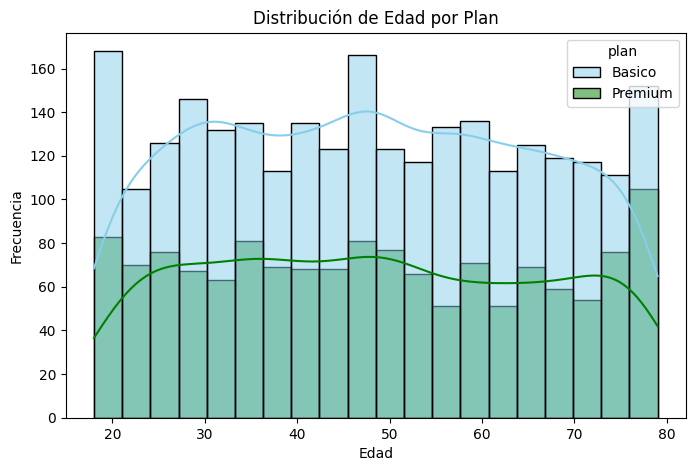

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt
# Histograma para visualizar la edad (age)

plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue','green'],
    bins=20,
    kde=True
)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ... La distribución de edad parece simétrica. No veo diferencias marcadas entre plan Básico y Premium en términos de edad. No parece existir segmentación por plan.

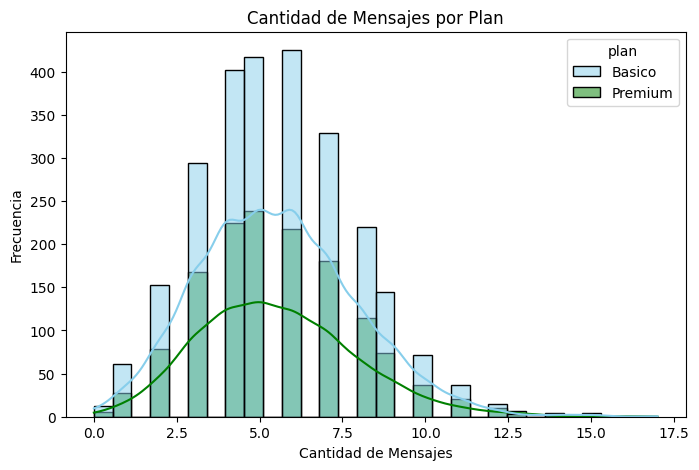

In [163]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue','green'],
    bins=30,
    kde=True
)
plt.title('Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- .... La distribución puede estar un poco sesgada a la derecha (muchos usuarios envían pocos mensajes, pocos envían muchos). Ambos planes y curvas se ven parecidos. Pero los usuarios Premium tienen mayor volumen de mensajes.

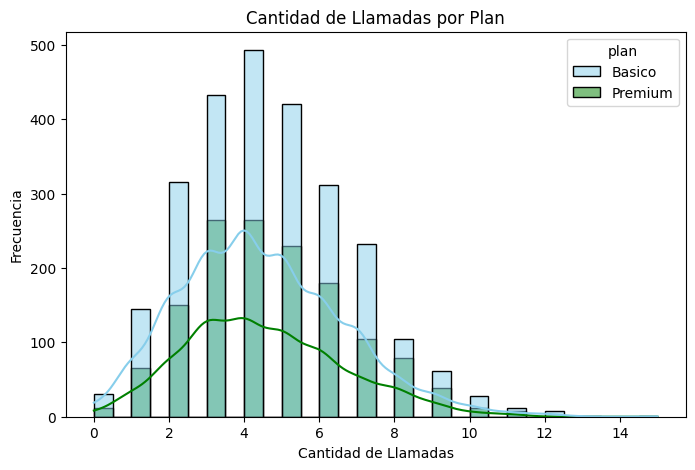

In [164]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue','green'],
    bins=30,
    kde=True
)
plt.title('Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ... Se observa leve sesgo a la derecha. Como Premium tiene cola ligeramente más larga significa mayor intensidad de uso.

Aunque no hay diferencia visual significativa → comportamiento similar entre planes.

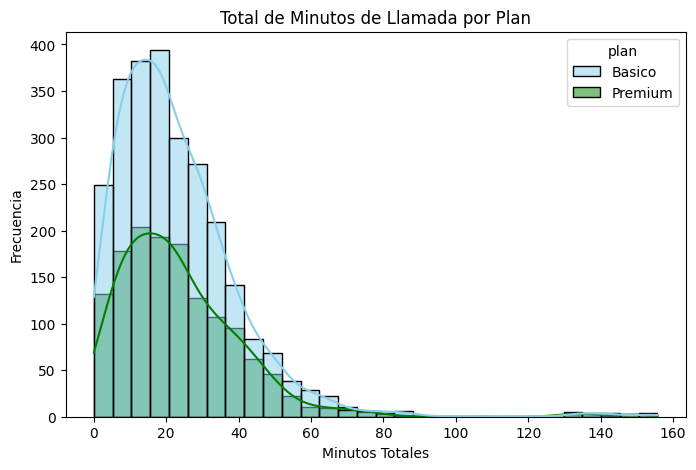

In [165]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8,5))
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue','green'],
    bins=30,
    kde=True
)
plt.title('Total de Minutos de Llamada por Plan')
plt.xlabel('Minutos Totales')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- ...

fuerte sesgo a la derecha. En esta variable se identifican outliers claros.
Premium muestra mayor dispersión lo que se puede traducir en mayor consumo promedio.

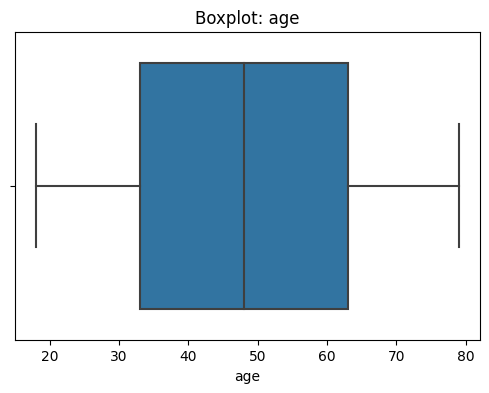

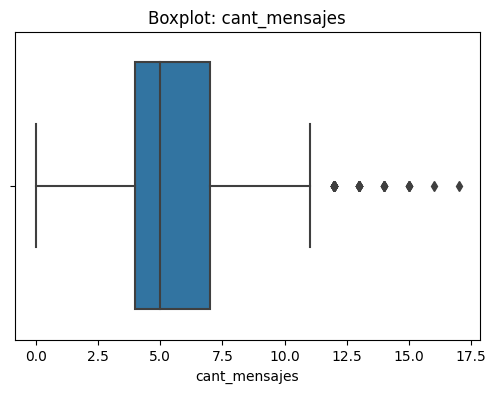

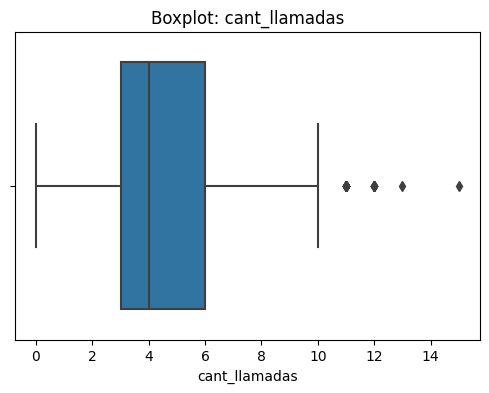

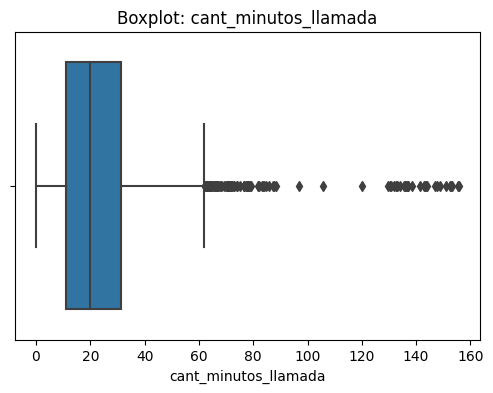

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 

Age: No presenta outliers relevantes después de haber corregido el sentinel. La distribución debería estar dentro del rango (18–79).

Cant_mensajes: Es común tener outliers superiores debido a usuarios con alto volumen de mensajería. Distribución sesgada a la derecha.

Cant_llamadas: Presenta algunos outliers superiores supongo que debido a algunos "heavy users".

Cant_minutos_llamada: Es la variable con más outliers superiores debido a usuarios con consumo intensivo.

In [167]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    limite_inferior = Q1 - 1.5 * IQR
    
    print(f'\nVariable: {col}')
    print(f'Límite inferior: {limite_inferior}')
    print(f'Límite superior: {limite_superior}')
    print(f'Máximo observado: {user_profile[col].max()}')




Variable: cant_mensajes
Límite inferior: -0.5
Límite superior: 11.5
Máximo observado: 17.0

Variable: cant_llamadas
Límite inferior: -1.5
Límite superior: 10.5
Máximo observado: 15.0

Variable: cant_minutos_llamada
Límite inferior: -19.35
Límite superior: 61.870000000000005
Máximo observado: 155.69


In [168]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

Diagnóstico técnico y decisión
1. Cant_mensajes - existen outliers superiores. se recomienda mantenerlos, porque representan comportamiento real de heavy users, no errores de captura.
2. Cant_llamadas - supera el límite superior, son usuarios con alta frecuencia de llamadas. Se recomienda: Mantenerlos, ya que es normal tener usuarios intensivos.
3. Cant_minutos_llamada - Es la variable que màs excede el límite IQR, debe mantenerse, salvo que los valores sean absurdamente altos (por ejemplo. más minutos que horas posibles en el período).

In [170]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'  # valor por defecto

user_profile.loc[
    (user_profile['cant_llamadas'] < 5) & 
    (user_profile['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

user_profile.loc[
    (user_profile['cant_llamadas'] < 10) & 
    (user_profile['cant_mensajes'] < 10) &
    (user_profile['grupo_uso'] != 'Bajo uso'),
    'grupo_uso'
] = 'Uso medio'

In [171]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_llamadas,cant_mensajes,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,3.0,7.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,10.0,5.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,2.0,5.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,3.0,11.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,3.0,4.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [177]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

user_profile.loc[
    (user_profile['age'] < 60) & 
    (user_profile['age'] >= 30),
    'grupo_edad'
] = 'Adulto'

In [178]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_llamadas,cant_mensajes,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022.0,3.0,7.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022.0,10.0,5.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022.0,2.0,5.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022.0,3.0,11.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022.0,3.0,4.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

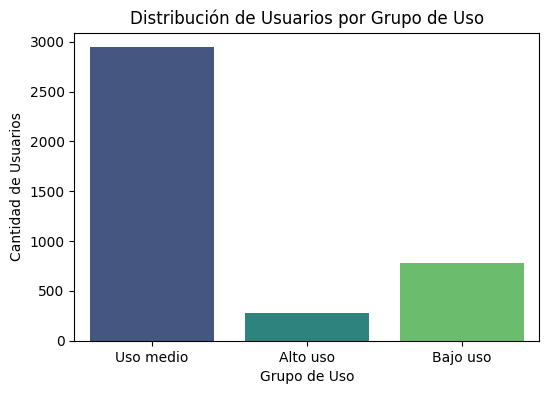

In [179]:
import seaborn as sns
import matplotlib.pyplot as plt
# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

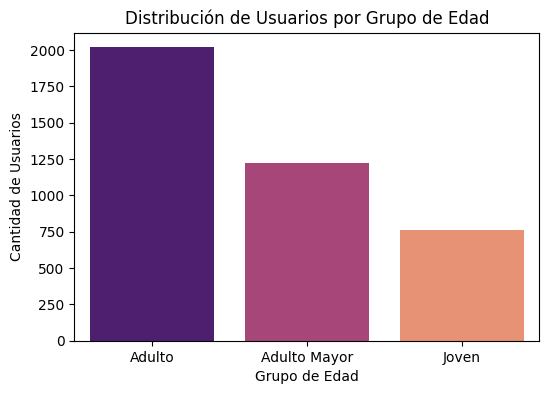

In [180]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_edad', palette='magma')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante la fase de limpieza se identificaron las siguientes inconsistencias:

Sentinel en edad (-999): Representaba registros inválidos que distorsionaban la media.
Fue reemplazado por la mediana para preservar la distribución.

Valores “?” en city: Correspondían a pocos datos faltantes. Fueron convertidos a valores nulos.

Fechas fuera de rango (año 2026): Se detectaron aproximadamente 40 registros con fechas futuras en reg_date. Representaban cerca del 1% del total y fueron marcadas como NaT.

Valores nulos en duration y length: No eran errores, sino valores estructurales dependientes del tipo de evento (call o text). Se decidió conservarlos.

Conclusión: Los problemas eran principalmente de calidad de captura, no estructurales. El dataset quedó consistente tras la limpieza.


🔍 **Segmentos por Edad**
Adultos (30–59): ~50%
Adulto Mayor (≥60): ~31%
Jóvenes (<30): ~19%

Comportamiento observado: Base de clientes predominantemente madura. Alta presencia de adultos mayores, lo que sugiere estabilidad. Segmento joven relativamente pequeño.


📊 **Segmentos por Nivel de Uso**
Uso Medio: ~75%
Bajo Uso: ~20%
Alto Uso: ~12%

Comportamiento: La mayoría de usuarios presenta consumo moderado. Existe un grupo reducido pero estratégico de heavy users. Bajo uso puede indicar clientes subutilizando su plan.


➡️ Esto sugiere que ...El segmento más estratégico parece ser: Adultos + Alto Uso

Porque: Mayor volumen de consumo. Potencialmente mayor facturación. Posibles candidatos naturales a plan Premium. También: Adultos mayores podrían ser clientes estables con baja rotación.

Jóvenes representan oportunidad de expansión.

Patrones de uso extremo (Outliers). Se identificaron outliers superiores en:

Cantidad de mensajes, Cantidad de llamadas, Minutos totales de llamada. Estos no representan errores, sino heavy users reales o clientes con consumo significativamente alto.

Posible riesgo de congestión si el pricing no está alineado. Oportunidad para planes premium ilimitados o diferenciados. La distribución es sesgada a la derecha, típica en telecom.

💡 **Recomendaciones**

1. Rediseñar estructura de planes: Crear un plan “Heavy User” con beneficios en minutos ilimitados. y Diseñar plan económico enfocado en Bajo Uso.

2. Estrategia diferenciada por edad: Adultos mayores → enfoque en llamadas y simplicidad. 
Jóvenes → enfoque en mensajería y beneficios digitales.

3. Upselling dirigido - Cruzar: Grupo Alto Uso + Plan Básico → Oportunidad directa de migración a Premium.

4. Monitoreo continuo de outliers: Los heavy users deben analizarse periódicamente para detectar fraude, Para ajustar pricing y diseñar ofertas exclusivas.

Conclusión Final

ConnectaTel tiene una base estable, predominantemente adulta, con consumo mayormente moderado y un segmento pequeño pero rentable de heavy users.

La oportunidad estratégica está en: Monetizar mejor a los usuarios de alto consumo. Activar el segmento de bajo uso. Diseñar ofertas diferenciadas por edad y comportamiento. El análisis revela oportunidades claras de optimización comercial y segmentación avanzada.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`